<a href="https://colab.research.google.com/github/aluminium5/Hack-O-Week-Sem-V-2026-27/blob/main/Week_9_10_End_to_End_ML_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hack-o-week — Weeks 9 & 10: End-to-End ML Workflow & Clustering

A complete Scikit-learn workflow covering preprocessing, feature engineering, evaluation, interpretation and clustering.

## Dataset
This notebook uses **Real estate valuation data set.csv**. The target variable is `Y house price of unit area`.

The dataset contains **414 rows and 8 columns**.

## Learning objectives
- Perform train/test splitting correctly.
- Handle missing data.
- Scale numerical features.
- Build reproducible Scikit-learn pipelines.
- Use cross-validation.
- Evaluate classification with confusion matrix, precision, recall, F1 and ROC-AUC.
- Interpret regression metrics.
- Apply K-Means, Hierarchical Clustering and DBSCAN.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("Real estate valuation data set.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA

data = df.copy()
target_reg = "Y house price of unit area"

features = [
    "X2 house age",
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "X5 latitude",
    "X6 longitude"
]

X = data[features]
y_reg = data[target_reg]
y_cls = (y_reg >= y_reg.median()).astype(int)

print("Missing values before preprocessing:")
print(X.isna().sum())

Missing values before preprocessing:
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
dtype: int64


## 1. Feature engineering

In [4]:
X_fe = X.copy()
X_fe["mrt_distance_km"] = X_fe["X3 distance to the nearest MRT station"] / 1000
X_fe["stores_per_km"] = (
    X_fe["X4 number of convenience stores"] /
    (X_fe["mrt_distance_km"] + 0.1)
)

X_fe.head()

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,mrt_distance_km,stores_per_km
0,32.0,84.87882,10,24.98298,121.54024,0.084879,54.089484
1,19.5,306.59470,9,24.98034,121.53951,0.306595,22.135065
2,13.3,561.98450,5,24.98746,121.54391,0.561984,7.553047
3,13.3,561.98450,5,24.98746,121.54391,0.561984,7.553047
4,5.0,390.56840,5,24.97937,121.54245,0.390568,10.192259


## 2. Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y_reg, test_size=0.2, random_state=42
)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_fe, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

## 3. Preprocessing pipeline
The pipeline imputes missing values and standardizes features without leaking information from the test set into training.

In [6]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, list(X_fe.columns))
])

## 4. Complete Scikit-learn workflow — regression

In [7]:
regression_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", Ridge(alpha=1.0))
])

regression_pipeline.fit(X_train, y_train)
pred_reg = regression_pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_reg))
print("RMSE:", mean_squared_error(y_test, pred_reg) ** 0.5)
print("R²:", r2_score(y_test, pred_reg))

MAE: 5.170637970166567
RMSE: 7.40608177057134
R²: 0.67304404671546


## 5. Cross-validation

In [8]:
cv_scores = cross_val_score(
    regression_pipeline,
    X_fe,
    y_reg,
    cv=5,
    scoring="r2"
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

CV R² scores: [0.67267336 0.59338219 0.70403925 0.45117604 0.59322098]
Mean CV R²: 0.6028983651504971


## 6. Complete Scikit-learn workflow — classification

In [9]:
classification_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

classification_pipeline.fit(Xc_train, yc_train)

pred_cls = classification_pipeline.predict(Xc_test)
prob_cls = classification_pipeline.predict_proba(Xc_test)[:, 1]

print(classification_report(yc_test, pred_cls))
print("Precision:", precision_score(yc_test, pred_cls))
print("Recall:", recall_score(yc_test, pred_cls))
print("F1:", f1_score(yc_test, pred_cls))
print("ROC-AUC:", roc_auc_score(yc_test, prob_cls))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80        42
           1       0.76      0.93      0.84        41

    accuracy                           0.82        83
   macro avg       0.83      0.82      0.82        83
weighted avg       0.84      0.82      0.82        83

Precision: 0.76
Recall: 0.926829268292683
F1: 0.8351648351648352
ROC-AUC: 0.894308943089431


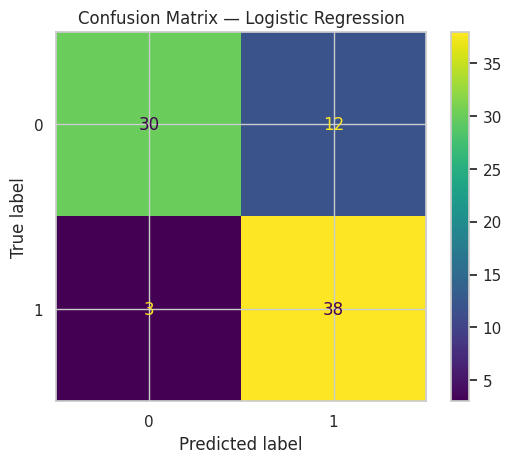

In [10]:
cm = confusion_matrix(yc_test, pred_cls)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

## 7. ROC-AUC
ROC-AUC evaluates how well the model ranks positive observations above negative observations across classification thresholds.

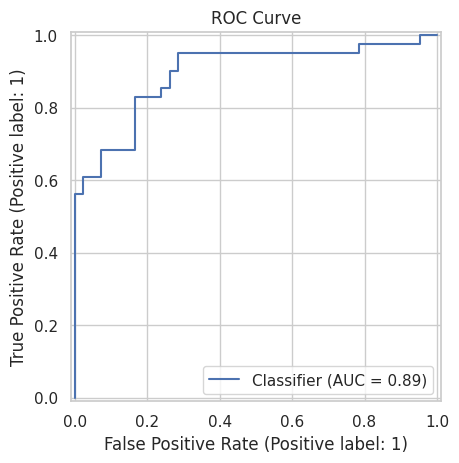

In [11]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(yc_test, prob_cls)
plt.title("ROC Curve")
plt.show()

## 8. Clustering dataset
Clustering is unsupervised, so the price target is excluded. We standardize the real-estate features before distance-based clustering.

In [12]:
cluster_features = X_fe.copy()

cluster_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Z_cluster = cluster_preprocessor.fit_transform(cluster_features)
print(Z_cluster.shape)

(414, 7)


## 9. K-Means

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(Z_cluster)

clustered = data.copy()
clustered["kmeans_cluster"] = kmeans_labels
clustered.groupby("kmeans_cluster")[target_reg].agg(["count", "mean", "median"])

,count,mean,median
kmeans_cluster,,,
0,166,32.271687,29.95
1,212,45.764623,44.40
2,36,18.461111,17.40


## 10. Hierarchical clustering

In [14]:
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(Z_cluster)

clustered["hierarchical_cluster"] = hierarchical_labels
clustered.groupby("hierarchical_cluster")[target_reg].agg(["count", "mean"])

,count,mean
hierarchical_cluster,,
0,203,34.523645
1,36,18.461111
2,175,46.005143


## 11. DBSCAN

In [15]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(Z_cluster)

clustered["dbscan_cluster"] = dbscan_labels
print(pd.Series(dbscan_labels).value_counts().sort_index())

-1     11
 0    358
 1     31
 2      7
 3      7
Name: count, dtype: int64


## 12. Visualize clusters using PCA

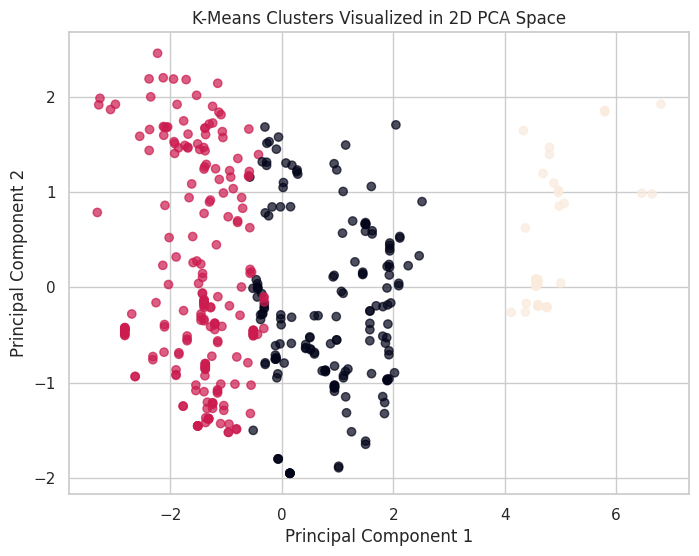

In [16]:
pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z_cluster)

plt.figure(figsize=(8,6))
plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=kmeans_labels, alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized in 2D PCA Space")
plt.show()

## Week 9–10 final task
Prepare a short report containing:
1. The preprocessing decisions you made.
2. A comparison of at least two supervised models.
3. Train/test and cross-validation results.
4. Confusion matrix and precision/recall/F1/ROC-AUC for classification.
5. K-Means, Hierarchical and DBSCAN cluster results.
6. Two useful business/data insights from the models or clusters.
7. A brief limitation section explaining why the results should not be interpreted as causal conclusions.

## Final workflow checklist
**Load → inspect → clean → feature engineer → split → preprocess → pipeline → train → cross-validate → evaluate → interpret → cluster → communicate results.**

## Conclusion
This notebook completes the end-to-end Scikit-learn machine-learning workflow requested for Weeks 9–10.